<a href="https://colab.research.google.com/github/natalipro12/MydataprogectsAPI/blob/main/gmailapi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# **Gmai box  cleaning using API  connetion**


# ** 1.# *Google Setup * **

Go to console.cloud.google.com

*   Create a project
 → Enable Gmail API
*   Go to Credentials → Create OAuth 2.0 Client ID → Desktop App
*  Download the JSON → rename it gmailclean.json












In [ ]:
!pip install --quiet google-api-python-client google-auth-httplib2 google-auth-oauthlib

In [ ]:
import json
from google_auth_oauthlib.flow import Flow

In [ ]:
#uploud API KEY for gmailclean.JSON from google cloud
from google.colab import files
uploaded = files.upload()

Saving client_secret_7m.json to client_secret_7m.json


In [ ]:
from google_auth_oauthlib.flow import InstalledAppFlow
from googleapiclient.discovery import build

SCOPES = ["https://mail.google.com/"]




```
# cnnect to yoiur mailbox/ each reload of this code or connection rror may requer reuploud new link connection . after pas key to box , just press enter
```



In [ ]:

# Use the correct filename
credentials_file = next(iter(uploaded))
flow = Flow.from_client_secrets_file(
    credentials_file,
    scopes=SCOPES,
    redirect_uri="urn:ietf:wg:oauth:2.0:oob"
)

auth_url, _ = flow.authorization_url(prompt="consent")
print("👉 Open this URL in your browser:")
print(auth_url)
print("\nThen paste the code you get below:")
code = input("Enter the code: ")
flow.fetch_token(code=code)
creds = flow.credentials

👉 Open this URL in your browser:
https://accounts.google.com/o/oauth2/auth?response_type=code&client_id=786165102191-7c73p3ugnsifvh64ua8c5g0l23l13mv2.apps.googleusercontent.com&redirect_uri=urn%3Aietf%3Awg%3Aoauth%3A2.0%3Aoob&scope=https%3A%2F%2Fmail.google.com%2F&state=mKWLgJAP0t8Gb436UkurCpLRp67CcE&code_challenge=n1-GjpohLE38Gwppg0zUFFZu4X_5Y6zKSV0UQd1EvSI&code_challenge_method=S256&prompt=consent&access_type=offline

Then paste the code you get below:
Enter the code: 4/1AdkVLPzzuxLtaO2Dub8Djs2Sjm-BufUGd1fer-FdN9UzXxHHEnMrI9IFQ48




*   build connection , in output will be  CONNECTED AS  yourmail.gmail.com
*   List item



In [ ]:
from googleapiclient.discovery import build
service = build("gmail", "v1", credentials=creds)
profile = service.users().getProfile(userId="me").execute()
print(f"✅ Connected as: {profile['emailAddress']}")

✅ Connected as: natalipro12@gmail.com




*   now reconnect to my gmail throw
api keyi   i wish to check data of my mail box



# Import libroaryes

In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from datetime import datetime, timezone
import math

# 2. Mail box statistics  by categoryes

#2.1 Get  total mails count

In [ ]:
# Get inbox total
profile     = service.users().getProfile(userId="me").execute()
inbox_total = profile.get("messagesTotal", 0)
print(f"\n  {'Inbox Total':<15} → {inbox_total:,}")



  Inbox Total     → 692


**2.2 Statistic by category and vizualistion by toyal amount and percent **


  Inbox Total     → 692
  Newsletters     → 9
  Spam/Promo      → 2
  Jobs            → 34
  Personal        → 188
  Unread          → 51
  Social          → 21
  Updates         → 24
  Draft           → 106
  Sent            → 342


/tmp/ipykernel_2680/3305333629.py:155: UserWarning: Glyph 128231 (\N{E-MAIL SYMBOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.04, 1, 1])
/tmp/ipykernel_2680/3305333629.py:155: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.04, 1, 1])
/tmp/ipykernel_2680/3305333629.py:156: UserWarning: Glyph 128231 (\N{E-MAIL SYMBOL}) missing from font(s) DejaVu Sans.
  plt.savefig("gmail_analysis.png", dpi=150, bbox_inches="tight", facecolor="#F8F9FA")
/tmp/ipykernel_2680/3305333629.py:156: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.savefig("gmail_analysis.png", dpi=150, bbox_inches="tight", facecolor="#F8F9FA")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128231 (\N{E-MAIL SYMBOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarnin

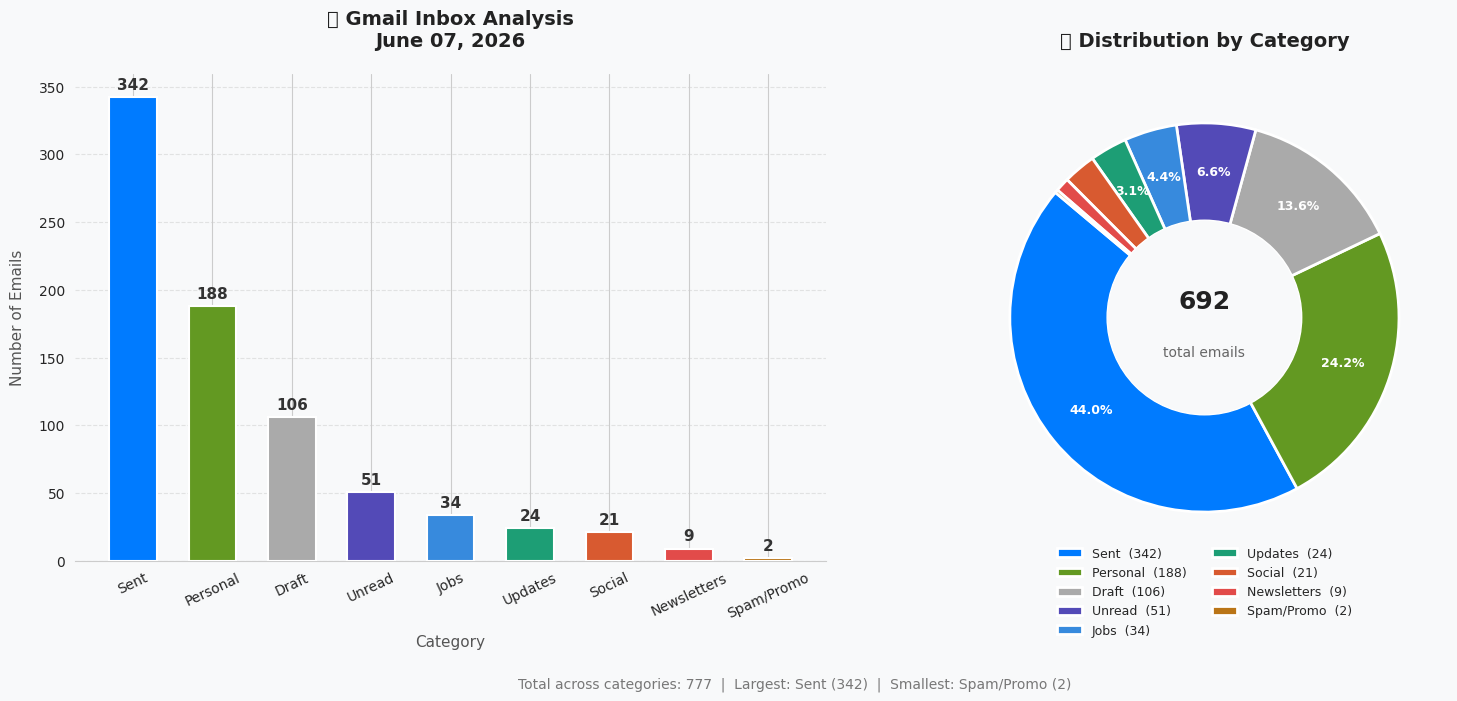


✅ Chart saved as gmail_analysis.png

📊 STATS SUMMARY
  Sent               342  (44.0%)
  Personal           188  (24.2%)
  Draft              106  (13.6%)
  Unread              51  (6.6%)
  Jobs                34  (4.4%)
  Updates             24  (3.1%)
  Social              21  (2.7%)
  Newsletters          9  (1.2%)
  Spam/Promo           2  (0.3%)
  ───────────────────────────────────
  TOTAL              777
  Inbox total        692


In [ ]:
#Get inbox total
profile     = service.users().getProfile(userId="me").execute()
inbox_total = profile.get("messagesTotal", 0)
print(f"\n  {'Inbox Total':<15} → {inbox_total:,}")

#Fetch category counts (re-initialized)
CATEGORIES = {
    "Newsletters"  : "category:promotions unsubscribe",
    "Spam/Promo"   : "category:promotions -unsubscribe",
    "Jobs"         : "subject:job OR subject:career OR from:linkedin OR from:indeed OR from:glassdoor OR from:jobleads",
    "Personal"     : "category:personal",
    "Unread"       : "is:unread",
    "Social"       : "category:social",
    "Updates"      : "category:updates",
    "Draft"        : "in:draft",
    "Sent"         : "in:sent"
}

counts = {}
for label, query in CATEGORIES.items():
    msgs, page_token = [], None
    while True:
        result = service.users().messages().list(
            userId="me", q=query,
            pageToken=page_token, maxResults=500
        ).execute()
        msgs.extend(result.get("messages", []))
        page_token = result.get("nextPageToken")
        if not page_token:
            break
    counts[label] = len(msgs)
    print(f"  {label:<15} → {len(msgs):,}")
    time.sleep(0.3)

# Prepare data
labels  = list(counts.keys())
values  = list(counts.values())
colors  = [
    "#E24B4A",   # Newsletters   — red
    "#BA7517",   # Spam/Promo    — orange
    "#378ADD",   # Jobs          — blue
    "#639922",   # Personal      — green
    "#534AB7",   # Unread        — purple
    "#D85A30",   # Social        — burnt orange
    "#1D9E75",   # Updates       — teal
    "#AAAAAA",   # Draft         — grey
    "#007bff",   # Sent          — darker blue
]

#Sort descending
sorted_data   = sorted(zip(values, labels, colors), reverse=True)
values_sorted = [x[0] for x in sorted_data]
labels_sorted = [x[1] for x in sorted_data]
colors_sorted = [x[2] for x in sorted_data]

# ─ Build chart
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor("#F8F9FA")

# ── Chart 1: Vertical bar chart
ax1 = axes[0]
ax1.set_facecolor("#F8F9FA")

bars = ax1.bar(
    labels_sorted, values_sorted,
    color=colors_sorted,
    width=0.6,
    edgecolor="white",
    linewidth=1.5,
    zorder=3
)

# Add value labels on top of each bar
for bar, val in zip(bars, values_sorted):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(values_sorted) * 0.01,
        f"{val:,}",
        ha="center", va="bottom",
        fontsize=11, fontweight="bold",
        color="#333333"
    )

ax1.set_title(
    f"📧 Gmail Inbox Analysis\n{datetime.now().strftime('%B %d, %Y')}",
    fontsize=14, fontweight="bold", pad=20, color="#222222"
)
ax1.set_xlabel("Category", fontsize=11, labelpad=10, color="#555555")
ax1.set_ylabel("Number of Emails", fontsize=11, labelpad=10, color="#555555")
ax1.tick_params(axis="x", rotation=25, labelsize=10)
ax1.tick_params(axis="y", labelsize=10)
ax1.yaxis.grid(True, linestyle="--", alpha=0.5, zorder=0)
ax1.set_axisbelow(True)
ax1.spines[["top","right","left"]].set_visible(False)

# ── Chart 2: Horizontal donut / pie
ax2 = axes[1]
ax2.set_facecolor("#F8F9FA")

wedges, texts, autotexts = ax2.pie(
    values_sorted,
    labels=None,
    colors=colors_sorted,
    autopct=lambda p: f"{p:.1f}%" if p > 3 else "",
    startangle=140,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
    pctdistance=0.75,
)

for at in autotexts:
    at.set_fontsize(9)
    at.set_fontweight("bold")
    at.set_color("white")

# Draw inner circle for donut effect
centre_circle = plt.Circle((0, 0), 0.50, fc="#F8F9FA")
ax2.add_artist(centre_circle)

ax2.text(
    0, 0.08, f"{inbox_total:,}",
    ha="center", va="center",
    fontsize=18, fontweight="bold", color="#222222"
)
ax2.text(
    0, -0.18, "total emails",
    ha="center", va="center",
    fontsize=10, color="#666666"
)

ax2.legend(
    wedges, [f"{l}  ({v:,})" for l, v in zip(labels_sorted, values_sorted)],
    loc="lower center",
    bbox_to_anchor=(0.5, -0.18),
    ncol=2,
    fontsize=9,
    frameon=False
)

ax2.set_title(
    "📊 Distribution by Category",
    fontsize=14, fontweight="bold", pad=20, color="#222222"
)

# ── Stats summary below charts
total_cats = sum(values_sorted)
fig.text(
    0.5, 0.01,
    f"Total across categories: {total_cats:,}  |  "
    f"Largest: {labels_sorted[0]} ({values_sorted[0]:,})  |  "
    f"Smallest: {labels_sorted[-1]} ({values_sorted[-1]:,})",
    ha="center", fontsize=10, color="#777777"
)

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig("gmail_analysis.png", dpi=150, bbox_inches="tight", facecolor="#F8F9FA")
plt.show()
print("\n✅ Chart saved as gmail_analysis.png")
print(f"\n📊 STATS SUMMARY")
print("=" * 40)
for l, v in zip(labels_sorted, values_sorted):
    pct = round(v / total_cats * 100, 1)
    print(f"  {l:<15} {v:>6,}  ({pct}%)")
print(f"  {'─'*35}")
print(f"  {'TOTAL':<15} {total_cats:>6,}")
print(f"  {'Inbox total':<15} {inbox_total:>6,}")

***2.3   Analyse average mails per week/month/year***

In [ ]:
#Determine total  mails,   incoming mails per week/month,year

print("🔍 Fetching all messages to analyze incoming mail by time period...")
print("=" * 70)

messages = []
page_token = None

while True:
    result = service.users().messages().list(
        userId="me", q="in:inbox", pageToken=page_token, maxResults=500
    ).execute()
    messages.extend(result.get("messages", []))
    page_token = result.get("nextPageToken")
    if not page_token:
        break

print(f"📬 Total {len(messages)} messages found in the inbox. Extracting dates...")

message_dates = []
# use  Limit to the first 10000 messages to avoid long processing times for large inboxes
messages_to_process = messages[:10000]

for i, msg in enumerate(messages_to_process):
    try:
        msg_detail = service.users().messages().get(
            userId="me", id=msg["id"],format="metadata", metadataHeaders=["Date"]
        ).execute()
        headers = {h["name"].lower(): h["value"] for h in msg_detail['payload']['headers']}
        date_str = headers.get("date", "")

        # Attempt to parse various date formats that include timezone info
        if date_str:
            try:
                date_obj = datetime.strptime(date_str, "%a, %d %b %Y %H:%M:%S %z")
            except ValueError:
                try:
                    date_obj = datetime.strptime(date_str, "%d %b %Y %H:%M:%S %z")
                except ValueError:
                    try:
                        date_obj = datetime.strptime(date_str, "%a, %d %b %Y %H:%M:%S %Z")
                    except ValueError:
                        # Fallback to internalDate if date header is problematic or not parseable
                        # Ensure it's timezone-aware (UTC) to avoid comparison errors
                        date_obj = datetime.fromtimestamp(int(msg_detail['internalDate']) / 1000, tz=timezone.utc)
            message_dates.append(date_obj)
    except Exception as e:
        # print(f"Error processing message {msg['id']}: {e}") # Uncomment for debugging
        pass
    if (i + 1) % 100 == 0:
        print(f"   Processed {i + 1}/{len(messages_to_process)} messages...")
    time.sleep(0.01) # Small delay to respect API limits

print("✅ All message dates extracted. Analyzing frequencies...")

if not message_dates:
    print("No valid message dates found for analysis.")
else:
    # Sort dates to ensure proper time range calculation
    message_dates.sort()
    min_date = message_dates[0]
    max_date = message_dates[-1]
    total_days = (max_date - min_date).days + 1

    if total_days <= 0:
        print("Not enough date range to perform weekly, monthly, yearly analysis.")
    else:
        # Group by week, month, year
        weekly_counts  = Counter(date.isocalendar() for date in message_dates)
        monthly_counts = Counter(date.strftime("%Y-%m") for date in message_dates)
        yearly_counts  = Counter(date.year for date in message_dates)

        # Calculate averages
        total_weeks  = math.ceil(total_days / 7)
        total_months = ((max_date.year - min_date.year) * 12 + max_date.month - min_date.month) + 1
        total_years  = max_date.year - min_date.year + 1

        avg_weekly_mails  = sum(weekly_counts.values())  / total_weeks
        avg_monthly_mails = sum(monthly_counts.values()) / total_months
        avg_yearly_mails  = sum(yearly_counts.values())  / total_years

        print("\n📊 Incoming Mail Frequency Analysis:")
        print("=" * 70)
        print(f"- Total messages analyzed: {len(message_dates)}")
        print(f"- Date range: {min_date.strftime('%Y-%m-%d')} to {max_date.strftime('%Y-%m-%d')}")
        print(f"- Total days in range: {total_days}")
        print("-")
        print(f"- Average incoming mails per week:  {avg_weekly_mails:.2f}")
        print(f"- Average incoming mails per month: {avg_monthly_mails:.2f}")
        print(f"- Average incoming mails per year:  {avg_yearly_mails:.2f}")
        print("=" * 70)

🔍 Fetching all messages to analyze incoming mail by time period...
📬 Total 230 messages found in the inbox. Extracting dates...
   Processed 100/230 messages...
   Processed 200/230 messages...
✅ All message dates extracted. Analyzing frequencies...

📊 Incoming Mail Frequency Analysis:
- Total messages analyzed: 230
- Date range: 2021-04-04 to 2026-06-07
- Total days in range: 1891
-
- Average incoming mails per week:  0.85
- Average incoming mails per month: 3.65
- Average incoming mails per year:  38.33


#3. Categorycal analyses


*  3.1 sort and count  income letters by category  in a body letter , meadata




In [ ]:
# Fetch category counts
CATEGORIES = {
    "Newsletters"  : "category:promotions unsubscribe",
    "Spam/Promo"   : "category:promotions -unsubscribe",
    "Jobs"         : "subject:job OR subject:career OR from:linkedin OR from:indeed OR from:glassdoor OR from:jobleads",
    "Personal"     : "category:personal",
    "Unread"       : "is:unread",
    "Social"       : "category:social",
    "Updates"      : "category:updates",
}

counts = {}
for label, query in CATEGORIES.items():
    msgs, page_token = [], None
    while True:
        result = service.users().messages().list(
            userId="me", q=query,
            pageToken=page_token, maxResults=500
        ).execute()
        msgs.extend(result.get("messages", []))
        page_token = result.get("nextPageToken")
        if not page_token:
            break
    counts[label] = len(msgs)
    print(f"  {label:<15} → {len(msgs):,}")
    time.sleep(0.3)

  Newsletters     → 22
  Spam/Promo      → 4
  Jobs            → 34
  Personal        → 527
  Unread          → 89
  Social          → 21
  Updates         → 45


#

# 3.2  Fetching all Gmail folders/labels with email counts.


*   Each category count by total and unread



#

In [ ]:
print("📂 Fetching all Gmail folders/labels with email counts...")
print("=" * 50)

try:
    labels_response = service.users().labels().list(userId='me').execute()
    labels = labels_response.get('labels', [])

    if not labels:
        print("No labels found.")
    else:
        # Prepare a list to store label details
        label_details = []
        for label in labels:
            # Fetch detailed information for each label to get message counts
            detail = service.users().labels().get(userId='me', id=label['id']).execute()
            label_details.append({
                'name': detail['name'],
                'total_messages': detail.get('messagesTotal', 0),
                'unread_messages': detail.get('messagesUnread', 0)
            })

        # Sort labels alphabetically by name for cleaner output
        label_details.sort(key=lambda x: x['name'].lower())

        print(f"  {'Folder Name':<25} {'Total':>8} {'Unread':>8}")
        print(f"  {'-'*25} {'-'*8} {'-'*8}")
        for detail in label_details:
            print(f"  {detail['name']:<25} {detail['total_messages']:>8} {detail['unread_messages']:>8}")

    print("=" * 50)
    print("✅ All folders listed with counts!")

except Exception as e:
    print(f"An error occurred: {e}")

📂 Fetching all Gmail folders/labels with email counts...
  Folder Name                  Total   Unread
  ------------------------- -------- --------
  Accenture                      167        0
  CATEGORY_FORUMS                  3        0
  CATEGORY_PERSONAL              527       14
  CATEGORY_PROMOTIONS             26       19
  CATEGORY_SOCIAL                 21       17
  CATEGORY_UPDATES                45       31
  CHAT                             0        0
  DRAFT                          106        0
  IMPORTANT                      606       56
  INBOX                          554       83
  Job                             30        0
  payments                        22        0
  SENT                           342        8
  SPAM                            11       10
  STARRED                          8        0
  TRASH                            1        0
  UNREAD                          89       89
  Unwanted                         0        0
  YELLOW_STAR          

#3.3   Scan income letters incide specific category , to determine top senders   unique adresses


*   Replace  category type name to work with desirable group

*   Create vizualisation for output - top senders in assending oder
*  


*  
*   **3.3.1   Scanning CATEGORY_SOCIAL for top senders**











🔍 Scanning CATEGORY_SOCIAL for top senders...
📬 Total social emails found: 21
🔍 Extracting unique senders...

📊 Generating horizontal bar chart for top 10 social senders...


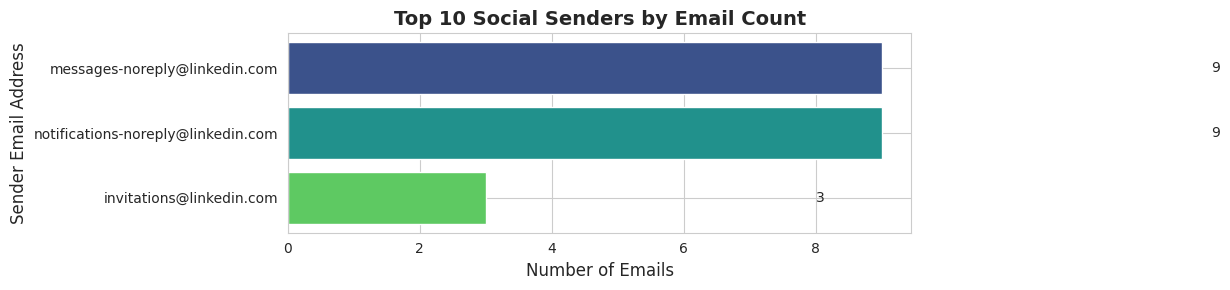


✅ Horizontal bar chart generated!

📊 TOP 10 SOCIAL SENDERS:
  messages-noreply@linkedin.com :     9
  notifications-noreply@linkedin.com :     9
  invitations@linkedin.com  :     3


In [ ]:
# Scanning CATEGORY_SOCIAL for top senders

print("🔍 Scanning CATEGORY_SOCIAL for top senders...")
print("=" * 55)

 Fetch all social emails
messages = []
page_token = None

while True:
    result = service.users().messages().list(
        userId="me",
        q="category:social",
        pageToken=page_token,
        maxResults=500
    ).execute()
    messages.extend(result.get("messages", []))
    page_token = result.get("nextPageToken")
    if not page_token:
        break

print(f"📬 Total social emails found: {len(messages)}")
print(f"🔍 Extracting unique senders...")

# --- Extract unique senders ───────────────────────────
sender_counter = Counter()

# Limiting the scan to the first 500 messages to avoid hitting API limits
# and for quicker processing, adjust as needed if more depth is required.
for i, msg in enumerate(messages[:500]):
    try:
        detail = service.users().messages().get(
            userId="me", id=msg["id"],
            format="metadata",
            metadataHeaders=["From"]
        ).execute()
        headers = {h["name"]: h["value"]
                   for h in detail.get("payload", {}).get("headers", [])}
        sender = headers.get("From", "Unknown Sender")
        match  = re.search(r'[\w\.-]+@[\w\.-]+', sender)
        if match:
            email = match.group(0).lower()
            sender_counter[email] += 1
        else:
            # If no email found, use the full 'From' header as a fallback
            sender_counter[sender] += 1
    except Exception as e:
        # print(f"Error processing message {msg['id']}: {e}") # uncomment for debugging
        pass
    if i % 100 == 0 and i > 0:
        print(f"   Scanned {i}/{min(500, len(messages))} messages...")
    time.sleep(0.01) # Small delay to respect API limits

# --- Get top 10 senders ──────────────────────────────
top_senders = sender_counter.most_common(10)
if not top_senders:
    print("No social senders found to analyze.")
else:
    senders = [item[0] for item in top_senders]
    counts  = [item[1] for item in top_senders]

    # --- Create horizontal bar chart ───────────────────
    print("\n📊 Generating horizontal bar chart for top 10 social senders...")

    sns.set_style("whitegrid")
    plt.figure(figsize=(15, 3))
    bars = plt.barh(senders, counts, color=sns.color_palette("viridis", len(senders)))

    plt.xlabel("Number of Emails", fontsize=12)
    plt.ylabel("Sender Email Address", fontsize=12)
    plt.title("Top 10 Social Senders by Email Count", fontsize=14, fontweight="bold")
    plt.gca().invert_yaxis() # Display top sender at the top

    # Add count labels on the bars
    for bar in bars:
        plt.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2, f'{int(bar.get_width()):,}',
                 va='center', ha='left', fontsize=10)

    plt.tight_layout()
    plt.show()

    print("\n✅ Horizontal bar chart generated!")
    print("\n📊 TOP 10 SOCIAL SENDERS:")
    print("=" * 30)
    for sender, count in top_senders:
        print(f"  {sender:<25} : {count:>5}")
    print("=" * 30)


# 3.3.2  CATEGORY_Jobs   for top senders

🔍 Scanning CATEGORY_Jobs   for top senders...
📬 Total jobs emails found: 128
🔍 Extracting unique senders...
   Scanned 100/128 messages...

📊 Generating horizontal bar chart for top 10 jobs senders...


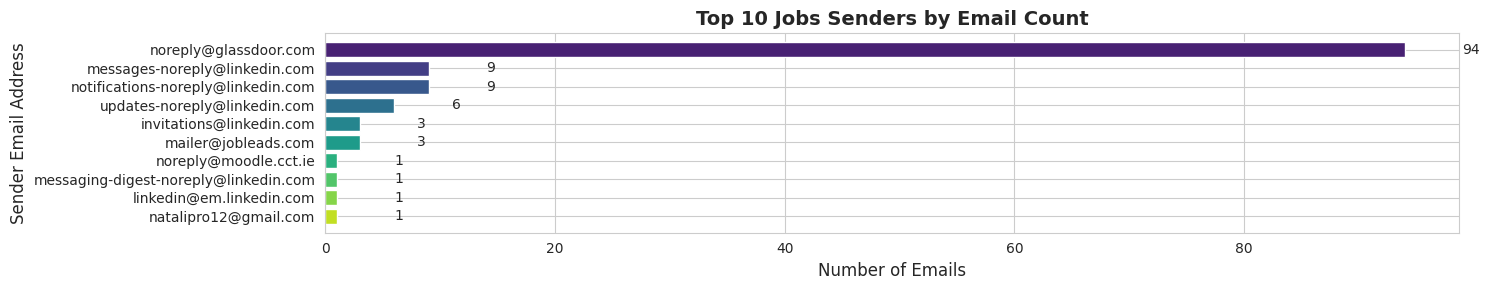


✅ Horizontal bar chart generated!

📊 TOP 5  Jobs   SENDERS:
  noreply@glassdoor.com     : 94
  messages-noreply@linkedin.com :  9
  notifications-noreply@linkedin.com :  9
  updates-noreply@linkedin.com :  6
  invitations@linkedin.com  :  3
  mailer@jobleads.com       :  3
  noreply@moodle.cct.ie     :  1
  messaging-digest-noreply@linkedin.com :  1
  linkedin@em.linkedin.com  :  1
  natalipro12@gmail.com     :  1


In [ ]:
#Scanning CATEGORY_Jobs   for top senders

print(" Scanning CATEGORY_Jobs   for top senders...")
print("=" * 55)

#Fetch all jobs emails
messages = []
page_token = None

while True:
    result = service.users().messages().list(
        userId="me",
        q=CATEGORIES["Jobs"],
        pageToken=page_token,
        maxResults=500
    ).execute()
    messages.extend(result.get("messages", []))
    page_token = result.get("nextPageToken")
    if not page_token:
        break

print(f" Total jobs emails found: {len(messages)}")
print(f" Extracting unique senders...")

# --- Extract unique senders ───────────────────────────
sender_counter = Counter()

# Limiting the scan to the first 500 messages to avoid hitting API limits
# and for quicker processing, adjust as needed if more depth is required.
for i, msg in enumerate(messages[:500]):
    try:
        detail = service.users().messages().get(
            userId="me", id=msg["id"],
            format="metadata",
            metadataHeaders=["From"]
        ).execute()
        headers = {h["name"]: h["value"]
                   for h in detail.get("payload", {}).get("headers", [])}
        sender = headers.get("From", "Unknown Sender")
        match  = re.search(r'[\w\.-]+@[\w\.-]+', sender)
        if match:
            email = match.group(0).lower()
            sender_counter[email] += 1
        else:
            # If no email found, use the full 'From' header as a fallback
            sender_counter[sender] += 1
    except Exception as e:
        # print(f"Error processing message {msg['id']}: {e}") # uncomment for debugging
        pass
    if i % 100 == 0 and i > 0:
        print(f"   Scanned {i}/{min(500, len(messages))} messages...")
    time.sleep(0.01) # Small delay to respect API limits

# --- Get top 10 senders ──────────────────────────────
top_senders = sender_counter.most_common(10)
if not top_senders:
    print("No  jobs   senders found to analyze.")
else:
    senders = [item[0] for item in top_senders]
    counts  = [item[1] for item in top_senders]

    # --- Create horizontal bar chart ───────────────────
    print("\n📊 Generating horizontal bar chart for top 10 jobs senders...")

    sns.set_style("whitegrid")
    plt.figure(figsize=(15, 3))
    bars = plt.barh(senders, counts, color=sns.color_palette("viridis", len(senders)))

    plt.xlabel("Number of Emails", fontsize=12)
    plt.ylabel("Sender Email Address", fontsize=12)
    plt.title("Top 10 Jobs Senders by Email Count", fontsize=14, fontweight="bold")
    plt.gca().invert_yaxis() # Display top sender at the top

    # Add count labels on the bars
    for bar in bars:
        plt.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2, f'{int(bar.get_width()):,}',
                 va='center', ha='left', fontsize=10)

    plt.tight_layout()
    plt.show()

    print("\n✅ Horizontal bar chart generated!")
    print("\n📊 TOP 5  Jobs   SENDERS:")
    print("=" * 30)
    for sender, count in top_senders:
        print(f"  {sender:<25} : {count:>2}")
    print("=" *10)

#4   Mail cleaning
4.1

 Delite letters from  particular sender    within category   

*  Replace gmail adress for your own and related category name


1.  noreply@glassdoor.com     : 94,    this sender  are most active,  as i no longer interested , i just dellite  all existed mails but filter   by group   JOBS








In [ ]:
sender_to_delete = "noreply@glassdoor.com"
jobs_category_query = CATEGORIES["Jobs"]

print(f"Deleting messages from {sender_to_delete} within the 'Jobs' category...")

deleted_count = 0
message_ids_to_delete = []

# Fetch messages from the specified sender within the 'Jobs' category
query = f"from:{sender_to_delete} AND ({jobs_category_query})"

page_token = None
while True:
    result = service.users().messages().list(
        userId="me",
        q=query,
        pageToken=page_token,
        maxResults=500
    ).execute()
    messages = result.get("messages", [])
    if not messages:
        break
    message_ids_to_delete.extend([msg["id"] for msg in messages])
    page_token = result.get("nextPageToken")
    if not page_token:
        break

if message_ids_to_delete:
    # Batch delete the messages
    service.users().messages().batchDelete(
        userId="me",
        body={'ids': message_ids_to_delete}
    ).execute()
    deleted_count = len(message_ids_to_delete)
    print(f"✅ Successfully deleted {deleted_count} emails from {sender_to_delete}.")
else:
    print(f"No emails found from {sender_to_delete} within the 'Jobs' category to delete.")

# Recalculate the total count for the 'Jobs' category
jobs_messages_after_delete = []
page_token = None
while True:
    result = service.users().messages().list(
        userId="me",
        q=jobs_category_query,
        pageToken=page_token,
        maxResults=500
    ).execute()
    messages = result.get("messages", [])
    if not messages:
        break
    jobs_messages_after_delete.extend(messages)
    page_token = result.get("nextPageToken")
    if not page_token:
        break

new_jobs_total = len(jobs_messages_after_delete)

print(f"\nSummary:")
print(f"- Deleted emails from {sender_to_delete}: {deleted_count}")
print(f"- New total count for 'Jobs' category: {new_jobs_total}")

Deleting messages from noreply@glassdoor.com within the 'Jobs' category...
✅ Successfully deleted 94 emails from noreply@glassdoor.com.

Summary:
- Deleted emails from noreply@glassdoor.com: 94
- New total count for 'Jobs' category: 34


delite  all messagies from     noreply@glassdoor.com    (  any choosen sender )  



#4.2  Search  and delite all mails by key word  UNSUBSCUBE


* commonly used  word UNSUBSCRIBE*   used by unwanted marketing or promo senders
*     change or add    words   to extend   filtering     (   promo     or other  )*
*code  output  count each unique sender,  if some    sender unwaanted  and number of letters unreasonuble ,  just  pic up mail adress from a list   and use   code    to    delite    all     this   mails *

*  Change to word    ** BOOKING **  to  identify and delite all related messagies











     





In [ ]:
# Find all emails containing "unsubscribe"
messages = []
page_token = None

print("🔍 Searching for emails with 'unsubscribe'...")

while True:
    result = service.users().messages().list(
        userId="me",
        q="unsubscribe",  # ← searches subject + body
        pageToken=page_token,
        maxResults=500
    ).execute()
    messages.extend(result.get("messages", []))
    page_token = result.get("nextPageToken")
    if not page_token:
        break

print(f"📬 Total emails found: {len(messages)}")

# Now group them by sender
print("\n🔍 Analyzing senders... (may take a moment)")

from collections import Counter
senders = []

for i, msg in enumerate(messages[:200]):  # Check first 200 to avoid quota
    details = service.users().messages().get(
        userId="me", id=msg["id"], format="metadata",
        metadataHeaders=["From"]
    ).execute()
    headers = details.get("payload", {}).get("headers", [])
    for h in headers:
        if h["name"] == "From":
            senders.append(h["value"])
    if i % 20 == 0:
        print(f"   Processed {i+1}/{min(200, len(messages))}...")

# Show top senders
print("\n📊 TOP SENDERS (unsubscribe emails):")
print("-" * 50)
counter = Counter(senders)
for sender, count in counter.most_common(20):
    print(f"  {count:4d} emails  ←  {sender}")

print("\n✅ Analysis complete!")


🔍 Searching for emails with 'unsubscribe'...
📬 Total emails found: 121

🔍 Analyzing senders... (may take a moment)
   Processed 1/121...
   Processed 21/121...
   Processed 41/121...
   Processed 61/121...
   Processed 81/121...
   Processed 101/121...
   Processed 121/121...

📊 TOP SENDERS (unsubscribe emails):
--------------------------------------------------
    13 emails  ←  Natali Rubymills <natalipro12@gmail.com>
    12 emails  ←  The Daily Rip by Stocktwits <newsletter@thedailyrip.stocktwits.com>
     9 emails  ←  LinkedIn <messages-noreply@linkedin.com>
     9 emails  ←  LinkedIn <notifications-noreply@linkedin.com>
     7 emails  ←  Revolut <no-reply@revolut.com>
     7 emails  ←  Cody From EverBee <hello@everbee.io>
     6 emails  ←  LinkedIn <updates-noreply@linkedin.com>
     4 emails  ←  AliExpress <ae-best-wishes-notify26@selections.aliexpress.com>
     4 emails  ←  Toyboy Warehouse <support@toyboywarehouse.com>
     3 emails  ←  Clayton Hotels <clayton@emails.claytonhot

# 4.2.1 "Searching for and deleting emails from {sender_to_unsubscribe}.

*  Code search particular mail adress    that contain  key word      UNSIBSCRIBE     anyweare inmetadata or name or body of the letter


*   sender_to_unsubscribe = "newsletter@thedailyrip.stocktwits.com"       replase      this mail for any you wish to filter   and   delete






In [ ]:
sender_to_unsubscribe = "newsletter@thedailyrip.stocktwits.com"

print(f"Searching for and deleting emails from {sender_to_unsubscribe}...")

deleted_count = 0
message_ids_to_delete = []

# Fetch messages from the specified sender
query = f"from:{sender_to_unsubscribe}"

page_token = None
while True:
    result = service.users().messages().list(
        userId="me",
        q=query,
        pageToken=page_token,
        maxResults=500
    ).execute()
    messages = result.get("messages", [])
    if not messages:
        break
    message_ids_to_delete.extend([msg["id"] for msg in messages])
    page_token = result.get("nextPageToken")
    if not page_token:
        break

if message_ids_to_delete:
    # Batch delete the messages
    service.users().messages().batchDelete(
        userId="me",
        body={'ids': message_ids_to_delete}
    ).execute()
    deleted_count = len(message_ids_to_delete)
    print(f"✅ Successfully deleted {deleted_count} emails from {sender_to_unsubscribe}.")
else:
    print(f"No emails found from {sender_to_unsubscribe} to delete.")

Searching for and deleting emails from newsletter@thedailyrip.stocktwits.com...
No emails found from newsletter@thedailyrip.stocktwits.com to delete.


**4.2.2   Top 10   Senders by Email Count in category   Social**


*  In this search can  filter  Social media notification , dting app  notificatons that can represent a decent chank of unwanted mails



📬 Total social emails found: 21
🔍 Extracting unique senders...

📊 Generating horizontal bar chart for top 10 social senders...


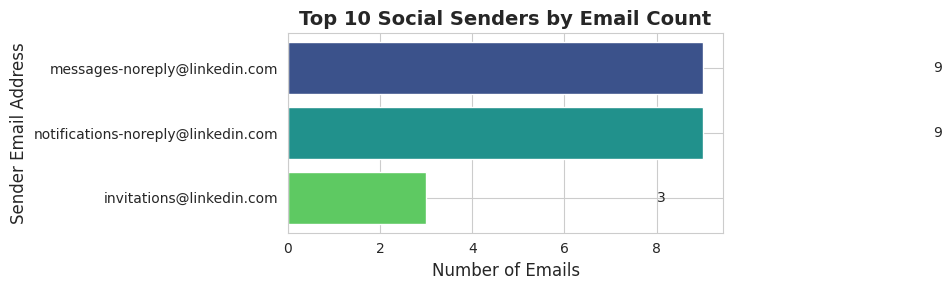


✅ Horizontal bar chart generated!

📊 TOP 10 SOCIAL SENDERS:
  messages-noreply@linkedin.com :     9
  notifications-noreply@linkedin.com :     9
  invitations@linkedin.com  :     3


In [ ]:


#  Fetch all social emails
messages = []
page_token = None

while True:
    result = service.users().messages().list(
        userId="me",
        q="category:social",
        pageToken=page_token,
        maxResults=500
    ).execute()
    messages.extend(result.get("messages", []))
    page_token = result.get("nextPageToken")
    if not page_token:
        break

print(f"📬 Total social emails found: {len(messages)}")
print(f"🔍 Extracting unique senders...")

# --- Extract unique senders ───────────────────────────
sender_counter = Counter()

# Limiting the scan to the first 500 messages to avoid hitting API limits
# and for quicker processing, adjust as needed if more depth is required.
for i, msg in enumerate(messages[:500]):
    try:
        detail = service.users().messages().get(
            userId="me", id=msg["id"],
            format="metadata",
            metadataHeaders=["From"]
        ).execute()
        headers = {h["name"]: h["value"]
                   for h in detail.get("payload", {}).get("headers", [])}
        sender = headers.get("From", "Unknown Sender")
        match  = re.search(r'[\w\.-]+@[\w\.-]+', sender)
        if match:
            email = match.group(0).lower()
            sender_counter[email] += 1
        else:
            # If no email found, use the full 'From' header as a fallback
            sender_counter[sender] += 1
    except Exception as e:
        # print(f"Error processing message {msg['id']}: {e}") # uncomment for debugging
        pass
    if i % 100 == 0 and i > 0:
        print(f"   Scanned {i}/{min(500, len(messages))} messages...")
    time.sleep(0.01) # Small delay to respect API limits

# --- Get top 10 senders ──────────────────────────────
top_senders = sender_counter.most_common(10)
if not top_senders:
    print("No social senders found to analyze.")
else:
    senders = [item[0] for item in top_senders]
    counts  = [item[1] for item in top_senders]

    # --- Create horizontal bar chart ───────────────────
    print("\n📊 Generating horizontal bar chart for top 10 social senders...")

    sns.set_style("whitegrid")
    plt.figure(figsize=(12, 3))
    bars = plt.barh(senders, counts, color=sns.color_palette("viridis", len(senders)))

    plt.xlabel("Number of Emails", fontsize=12)
    plt.ylabel("Sender Email Address", fontsize=12)
    plt.title("Top 10 Social Senders by Email Count", fontsize=14, fontweight="bold")
    plt.gca().invert_yaxis() # Display top sender at the top

    # Add count labels on the bars
    for bar in bars:
        plt.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2, f'{int(bar.get_width()):,}',
                 va='center', ha='left', fontsize=10)

    plt.tight_layout()
    plt.show()

    print("\n✅ Horizontal bar chart generated!")
    print("\n📊 TOP 10 SOCIAL SENDERS:")
    print("=" * 30)
    for sender, count in top_senders:
        print(f"  {sender:<25} : {count:>5}")
    print("=" * 30)


# 4.2.3  Scan and clean    category_name = FORUMS

*   output with   **Date:**    2021-02-24 08:10:31 UTC-08:00 and  Subject:
*  



In [ ]:
category_name = "CATEGORY_FORUMS"

# First, get the label ID for 'CATEGORY_FORUMS'
label_id = None
labels_response = service.users().labels().list(userId='me').execute()
labels = labels_response.get('labels', [])
for label in labels:
    if label['name'] == category_name:
        label_id = label['id']
        break

if not label_id:
    print(f"Error: Label '{category_name}' not found.")
else:
    print(f"🔍 Fetching all emails from '{category_name}' (ID: {label_id}) category...")

    messages_details = []
    page_token = None

    while True:
        result = service.users().messages().list(
            userId="me",
            labelIds=[label_id], # Use labelIds instead of 'q'
            pageToken=page_token,
            maxResults=500
        ).execute()
        messages = result.get("messages", [])
        if not messages:
            break

        for msg in messages:
            msg_detail = service.users().messages().get(
                userId="me",
                id=msg["id"],
                format="full" # Use 'full' to easily get payload for date
            ).execute()

            headers = {h["name"].lower(): h["value"] for h in msg_detail['payload']['headers']}

            subject = headers.get("subject", "No Subject")
            sender = headers.get("from", "Unknown Sender")
            date_str = headers.get("date", "")

            try:
 # Parse date string to datetime object for proper sorting

                date_obj = datetime.strptime(date_str, "%a, %d %b %Y %H:%M:%S %z")
            except ValueError:
                try:

                    date_obj = datetime.strptime(date_str, "%d %b %Y %H:%M:%S %z")
                except ValueError:
 # Fallback to internalDate if date header is problematic
                    date_obj = datetime.fromtimestamp(int(msg_detail['internalDate']) / 1000, tz=timezone.utc)

            messages_details.append({ "date": date_obj,"subject": subject,"sender": sender })

        page_token = result.get("nextPageToken")
        if not page_token:
            break

    if not messages_details:
        print(f"No emails found in '{category_name}' category.")
    else:
        # Sort messages by date in ascending order
        messages_details.sort(key=lambda x: x["date"])

        print(f"📬 Found {len(messages_details)} emails in '{category_name}' category. Listing in ascending order by date:")
        print("=" * 80)
        for msg_data in messages_details:
            print(f"Date:    {msg_data['date'].strftime('%Y-%m-%d %H:%M:%S %Z')}")
            print(f"From:    {msg_data['sender']}")
            print(f"Subject: {msg_data['subject']}")
            print("-" * 80)
        print("✅ Done listing emails.")

🔍 Fetching all emails from 'CATEGORY_FORUMS' (ID: CATEGORY_FORUMS) category...
📬 Found 3 emails in 'CATEGORY_FORUMS' category. Listing in ascending order by date:
Date:    2021-02-24 08:10:31 UTC-08:00
From:    xws via prohorova <prohorova@externalworkforce-noreply.google.com>
Subject: Partner Domain Deactivation
--------------------------------------------------------------------------------
Date:    2025-09-05 17:20:30 UTC
From:    urgent-notification <______________________________DXXL8PGQU__@rochaven.com>
Subject: Thanks for confirming!                                                                                                                                                                                                                                                                                                                                                                                                                                                                      

# 4.2.4 delete all emails from the category



*  In my mail box in this category only 3 mails, after rview data and Subject , i i decide to clean them all l if you need to clean specific mails only , use code to delite list of mails
*   List item



In [ ]:
category_to_delete = "CATEGORY_FORUMS"

print(f"🔍 Attempting to delete all emails from the category: '{category_to_delete}'...")

# First, get the label ID for the specified category
label_id_to_delete = None
labels_response = service.users().labels().list(userId='me').execute()
labels = labels_response.get('labels', [])
for label in labels:
    if label['name'] == category_to_delete:
        label_id_to_delete = label['id']
        break

if not label_id_to_delete:
    print(f"Error: Label '{category_to_delete}' not found. No emails deleted.")
else:
    print(f"Found label '{category_to_delete}' with ID: {label_id_to_delete}.")

    messages_to_delete_ids = []
    page_token = None

    # Fetch all messages under this label
    while True:
        result = service.users().messages().list(
            userId='me',
            labelIds=[label_id_to_delete],
            pageToken=page_token,
            maxResults=500
        ).execute()
        messages = result.get('messages', [])
        if not messages:
            break

        for msg in messages:
            messages_to_delete_ids.append(msg['id'])

        page_token = result.get('nextPageToken')
        if not page_token:
            break

    if not messages_to_delete_ids:
        print(f"No emails found in '{category_to_delete}' category to delete.")
    else:
        print(f"Found {len(messages_to_delete_ids)} emails in '{category_to_delete}'. Deleting now...")
        # Perform batch delete
        service.users().messages().batchDelete(
            userId='me',
            body={'ids': messages_to_delete_ids}
        ).execute()

        print(f"✅ Successfully deleted {len(messages_to_delete_ids)} emails from '{category_to_delete}'.")

        # Optionally, verify the count after deletion
        # This block can be removed if verification is not needed repeatedly
        print(f"\nVerifying remaining emails in '{category_to_delete}'...")
        remaining_messages = []
        page_token = None
        while True:
            result = service.users().messages().list(
                userId='me',
                labelIds=[label_id_to_delete],
                pageToken=page_token,
                maxResults=500
            ).execute()
            messages = result.get('messages', [])
            if not messages:
                break
            remaining_messages.extend(messages)
            page_token = result.get('nextPageToken')
            if not page_token:
                break
        print(f"Remaining emails in '{category_to_delete}': {len(remaining_messages)}")

🔍 Attempting to delete all emails from the category: 'CATEGORY_FORUMS'...
Found label 'CATEGORY_FORUMS' with ID: CATEGORY_FORUMS.
Found 3 emails in 'CATEGORY_FORUMS'. Deleting now...
✅ Successfully deleted 3 emails from 'CATEGORY_FORUMS'.

Verifying remaining emails in 'CATEGORY_FORUMS'...
Remaining emails in 'CATEGORY_FORUMS': 0


# 4.3.3  Analise   top senders in group of categories [CATEGORY_PROMOTIONS", "CATEGORY_SOCIAL", "CATEGORY_UPDATES"]

*   some mails can skip   filter by category , so we run scunning by the similar   group of categories



In [ ]:
import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import time


🔍 Scanning CATEGORY_PROMOTIONS for top senders...
📬 Total CATEGORY_PROMOTIONS emails found: 26
🔍 Extracting unique senders...

📊 Generating horizontal bar chart for top 10 CATEGORY_PROMOTIONS senders...


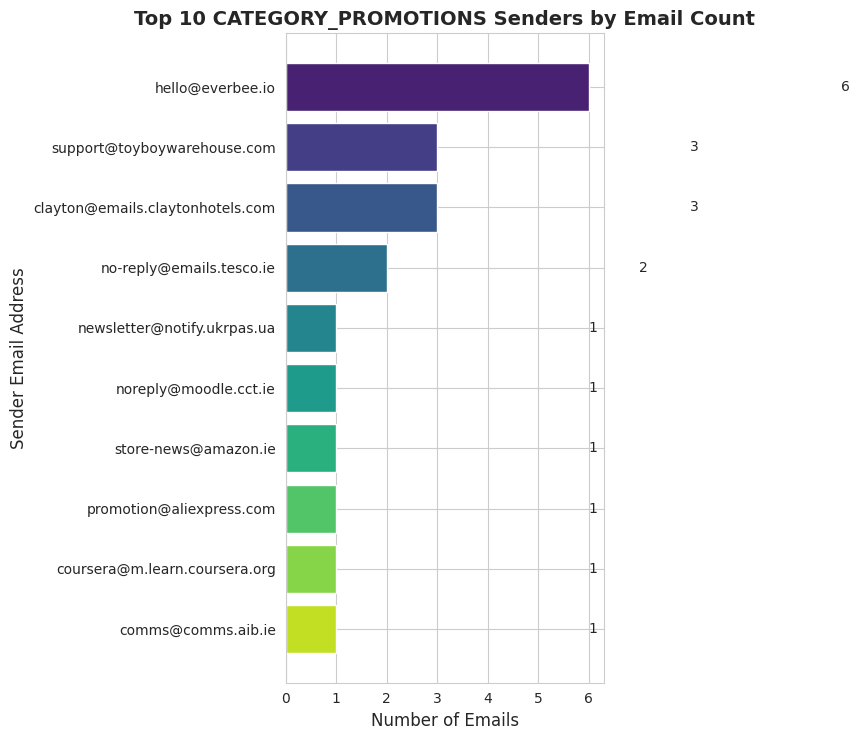


✅ Horizontal bar chart generated!

📊 TOP 10 CATEGORY_PROMOTIONS SENDERS:
  hello@everbee.io          :     6
  support@toyboywarehouse.com :     3
  clayton@emails.claytonhotels.com :     3
  no-reply@emails.tesco.ie  :     2
  newsletter@notify.ukrpas.ua :     1
  noreply@moodle.cct.ie     :     1
  store-news@amazon.ie      :     1
  promotion@aliexpress.com  :     1
  coursera@m.learn.coursera.org :     1
  comms@comms.aib.ie        :     1

🔍 Scanning CATEGORY_SOCIAL for top senders...
📬 Total CATEGORY_SOCIAL emails found: 21
🔍 Extracting unique senders...

📊 Generating horizontal bar chart for top 10 CATEGORY_SOCIAL senders...


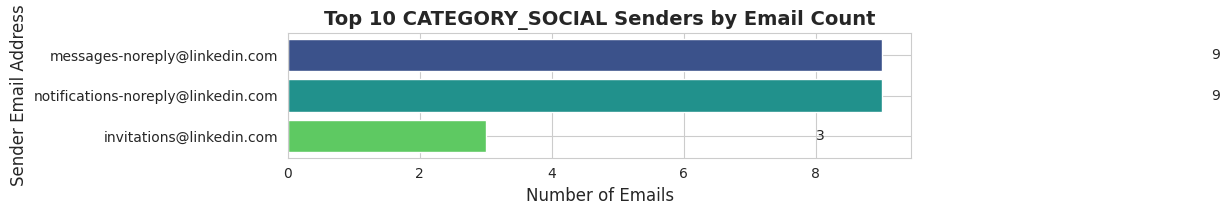


✅ Horizontal bar chart generated!

📊 TOP 10 CATEGORY_SOCIAL SENDERS:
  messages-noreply@linkedin.com :     9
  notifications-noreply@linkedin.com :     9
  invitations@linkedin.com  :     3

🔍 Scanning CATEGORY_UPDATES for top senders...
📬 Total CATEGORY_UPDATES emails found: 45
🔍 Extracting unique senders...

📊 Generating horizontal bar chart for top 10 CATEGORY_UPDATES senders...


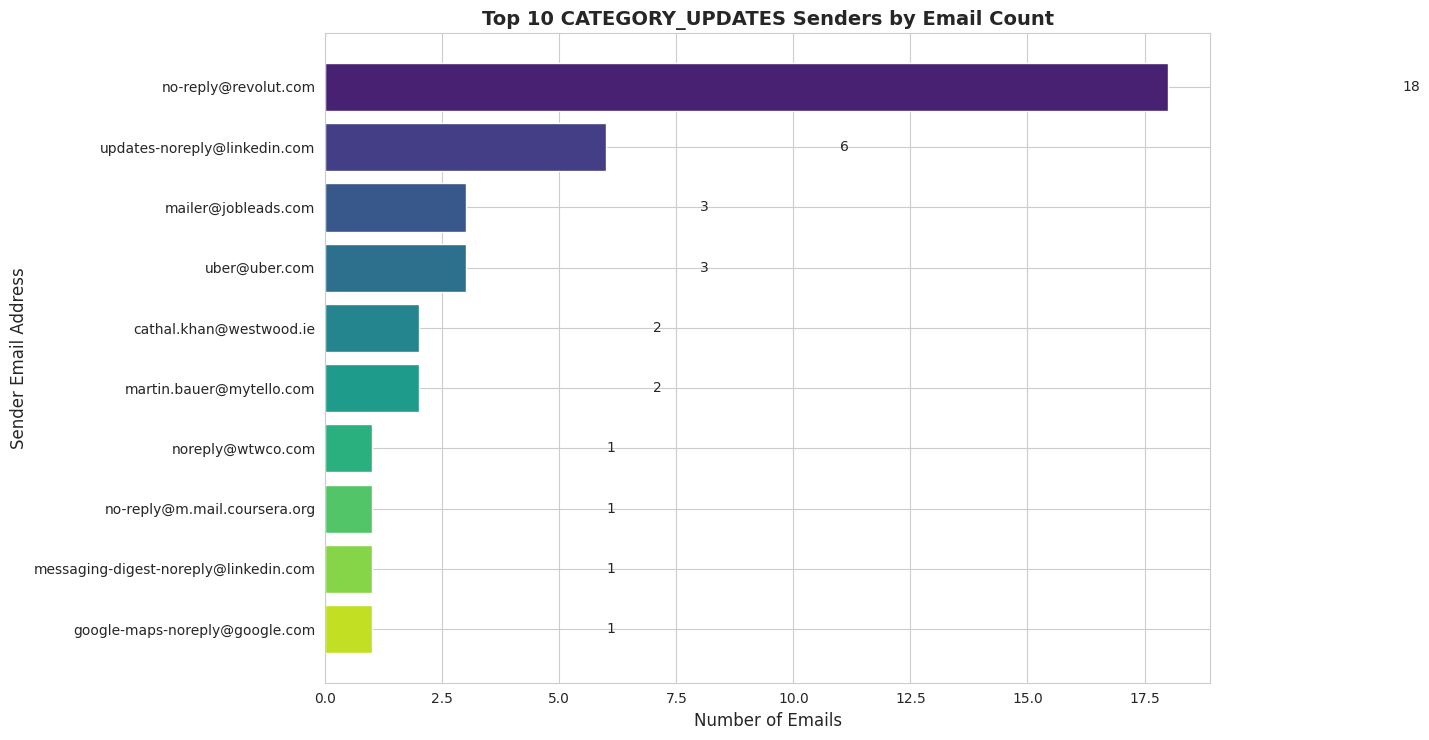


✅ Horizontal bar chart generated!

📊 TOP 10 CATEGORY_UPDATES SENDERS:
  no-reply@revolut.com      :    18
  updates-noreply@linkedin.com :     6
  mailer@jobleads.com       :     3
  uber@uber.com             :     3
  cathal.khan@westwood.ie   :     2
  martin.bauer@mytello.com  :     2
  noreply@wtwco.com         :     1
  no-reply@m.mail.coursera.org :     1
  messaging-digest-noreply@linkedin.com :     1
  google-maps-noreply@google.com :     1

🚀 Analysis complete for all requested categories!


In [ ]:


categories_to_analyze = ["CATEGORY_PROMOTIONS", "CATEGORY_SOCIAL", "CATEGORY_UPDATES"]

for category_name in categories_to_analyze:
    print(f"\n🔍 Scanning {category_name} for top senders...")
    print("=" * 55)

    # First, get the label ID for the current category
    label_id = None
    labels_response = service.users().labels().list(userId='me').execute()
    labels = labels_response.get('labels', [])
    for label in labels:
        if label['name'] == category_name:
            label_id = label['id']
            break

    if not label_id:
        print(f"Error: Label '{category_name}' not found. Skipping this category.\n")
        continue

    # --- Fetch all emails for the current category ──────────────────────────
    messages = []
    page_token = None

    while True:
        result = service.users().messages().list(
            userId="me",
            labelIds=[label_id], # Use labelIds for specific labels
            pageToken=page_token,
            maxResults=500
        ).execute()
        messages.extend(result.get("messages", []))
        page_token = result.get("nextPageToken")
        if not page_token:
            break

    print(f"📬 Total {category_name} emails found: {len(messages)}")
    print(f"🔍 Extracting unique senders...")

    # --- Extract unique senders ───────────────────────────
    sender_counter = Counter()

    # Limiting the scan to the first 500 messages to avoid hitting API limits
    # and for quicker processing. Adjust as needed if more depth is required.
    messages_to_scan = messages[:500]
    for i, msg in enumerate(messages_to_scan):
        try:
            detail = service.users().messages().get(
                userId="me", id=msg["id"],
                format="metadata",
                metadataHeaders=["From"]
            ).execute()
            headers = {h["name"].lower(): h["value"] for h in detail.get("payload", {}).get("headers", [])}
            sender = headers.get("from", "Unknown Sender")
            match  = re.search(r'[\w\.-]+@[\w\.-]+', sender)
            if match:
                email = match.group(0).lower()
                sender_counter[email] += 1
            else:
                # If no email found, use the full 'From' header as a fallback
                sender_counter[sender] += 1
        except Exception as e:
            # print(f"Error processing message {msg['id']}: {e}") # uncomment for debugging
            pass
        if (i + 1) % 100 == 0 and (i + 1) < len(messages_to_scan):
            print(f"   Scanned {i + 1}/{len(messages_to_scan)} messages...")
        time.sleep(0.01) # Small delay to respect API limits

    # --- Get top 10 senders ──────────────────────────────
    top_senders = sender_counter.most_common(10)
    if not top_senders:
        print(f"No senders found to analyze in '{category_name}'.")
    else:
        senders = [item[0] for item in top_senders]
        counts  = [item[1] for item in top_senders]

        # --- Create horizontal bar chart ───────────────────
        print(f"\n📊 Generating horizontal bar chart for top 10 {category_name} senders...")

        sns.set_style("whitegrid")
        plt.figure(figsize=(15, min(8, len(senders) * 0.75))) # Adjust height based on number of senders
        bars = plt.barh(senders, counts, color=sns.color_palette("viridis", len(senders)))

        plt.xlabel("Number of Emails", fontsize=12)
        plt.ylabel("Sender Email Address", fontsize=12)
        plt.title(f"Top 10 {category_name} Senders by Email Count", fontsize=14, fontweight="bold")
        plt.gca().invert_yaxis() # Display top sender at the top

        # Add count labels on the bars
        for bar in bars:
            plt.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2, f'{int(bar.get_width()):,}',
                     va='center', ha='left', fontsize=10)

        plt.tight_layout()
        plt.show()

        print("\n✅ Horizontal bar chart generated!")
        print(f"\n📊 TOP 10 {category_name} SENDERS:")
        print("=" * 30)
        for sender, count in top_senders:
            print(f"  {sender:<25} : {count:>5}")
        print("=" * 30)

print("\n🚀 Analysis complete for all requested categories!")

In [ ]:
Clean mailbox from list of senders



# *  Clean mailbox from list of senders
*   senders_to_delete_raw [   your list of senders   from group of categoryes scan }



In [ ]:

# Add   list of email senders.This code delite all mails from them

senders_to_delete_raw = """no-reply@revolut.com   ,hello@everbee.io
  support@toyboywarehouse.com
  clayton@emails.claytonhotels.com
  no-reply@emails.tesco.ie
  newsletter@notify.ukrpas.ua
  noreply@moodle.cct.ie
  store-news@amazon.ie
  promotion@aliexpress.com
  coursera@m.learn.coursera.org
  comms@comms.aib.ie  """

senders_to_delete = []
# Extract email addresses using regex, handling various formats
email_pattern = re.compile(r'[\w\.-]+@[\w\.-]+')
for line in senders_to_delete_raw.split('\n'):
    match = email_pattern.search(line)
    if match:
        senders_to_delete.append(match.group(0).lower())

if not senders_to_delete:
    print("No valid email addresses found in the provided list to delete.")
else:
    print(f"🔍 Initiating deletion for emails from the following senders: {', '.join(senders_to_delete)}")
    total_deleted_count = 0

    for sender_email in senders_to_delete:
        print(f"\nProcessing sender: {sender_email}")
        message_ids_to_delete = []
        page_token = None
        deleted_count_for_sender = 0

        # Fetch messages from the current sender
        query = f"from:{sender_email}"

        while True:
            result = service.users().messages().list(
                userId="me",
                q=query,
                pageToken=page_token,
                maxResults=500 # Fetch in batches
            ).execute()
            messages = result.get("messages", [])
            if not messages:
                break
            message_ids_to_delete.extend([msg["id"] for msg in messages])
            page_token = result.get("nextPageToken")
            if not page_token:
                break

        if message_ids_to_delete:
            # Perform batch delete
            service.users().messages().batchDelete(
                userId="me",
                body={'ids': message_ids_to_delete}
            ).execute()
            deleted_count_for_sender = len(message_ids_to_delete)
            total_deleted_count += deleted_count_for_sender
            print(f"✅ Successfully deleted {deleted_count_for_sender} emails from {sender_email}.")
        else:
            print(f"No emails found from {sender_email} to delete.")

    print(f"\nSummary: Total emails deleted across all specified senders: {total_deleted_count}")


🔍 Initiating deletion for emails from the following senders: no-reply@revolut.com, support@toyboywarehouse.com, clayton@emails.claytonhotels.com, no-reply@emails.tesco.ie, newsletter@notify.ukrpas.ua, noreply@moodle.cct.ie, store-news@amazon.ie, promotion@aliexpress.com, coursera@m.learn.coursera.org, comms@comms.aib.ie

Processing sender: no-reply@revolut.com
No emails found from no-reply@revolut.com to delete.

Processing sender: support@toyboywarehouse.com
No emails found from support@toyboywarehouse.com to delete.

Processing sender: clayton@emails.claytonhotels.com
No emails found from clayton@emails.claytonhotels.com to delete.

Processing sender: no-reply@emails.tesco.ie
No emails found from no-reply@emails.tesco.ie to delete.

Processing sender: newsletter@notify.ukrpas.ua
No emails found from newsletter@notify.ukrpas.ua to delete.

Processing sender: noreply@moodle.cct.ie
No emails found from noreply@moodle.cct.ie to delete.

Processing sender: store-news@amazon.ie
No emails f

# run final result


  Inbox Total     → 692
  Newsletters     → 9
  Spam/Promo      → 2
  Jobs            → 34
  Personal        → 188
  Unread          → 51
  Social          → 21
  Updates         → 24
  Draft           → 106
  Sent            → 342


/tmp/ipykernel_2680/3305333629.py:155: UserWarning: Glyph 128231 (\N{E-MAIL SYMBOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.04, 1, 1])
/tmp/ipykernel_2680/3305333629.py:155: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.04, 1, 1])
/tmp/ipykernel_2680/3305333629.py:156: UserWarning: Glyph 128231 (\N{E-MAIL SYMBOL}) missing from font(s) DejaVu Sans.
  plt.savefig("gmail_analysis.png", dpi=150, bbox_inches="tight", facecolor="#F8F9FA")
/tmp/ipykernel_2680/3305333629.py:156: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.savefig("gmail_analysis.png", dpi=150, bbox_inches="tight", facecolor="#F8F9FA")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128231 (\N{E-MAIL SYMBOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarnin

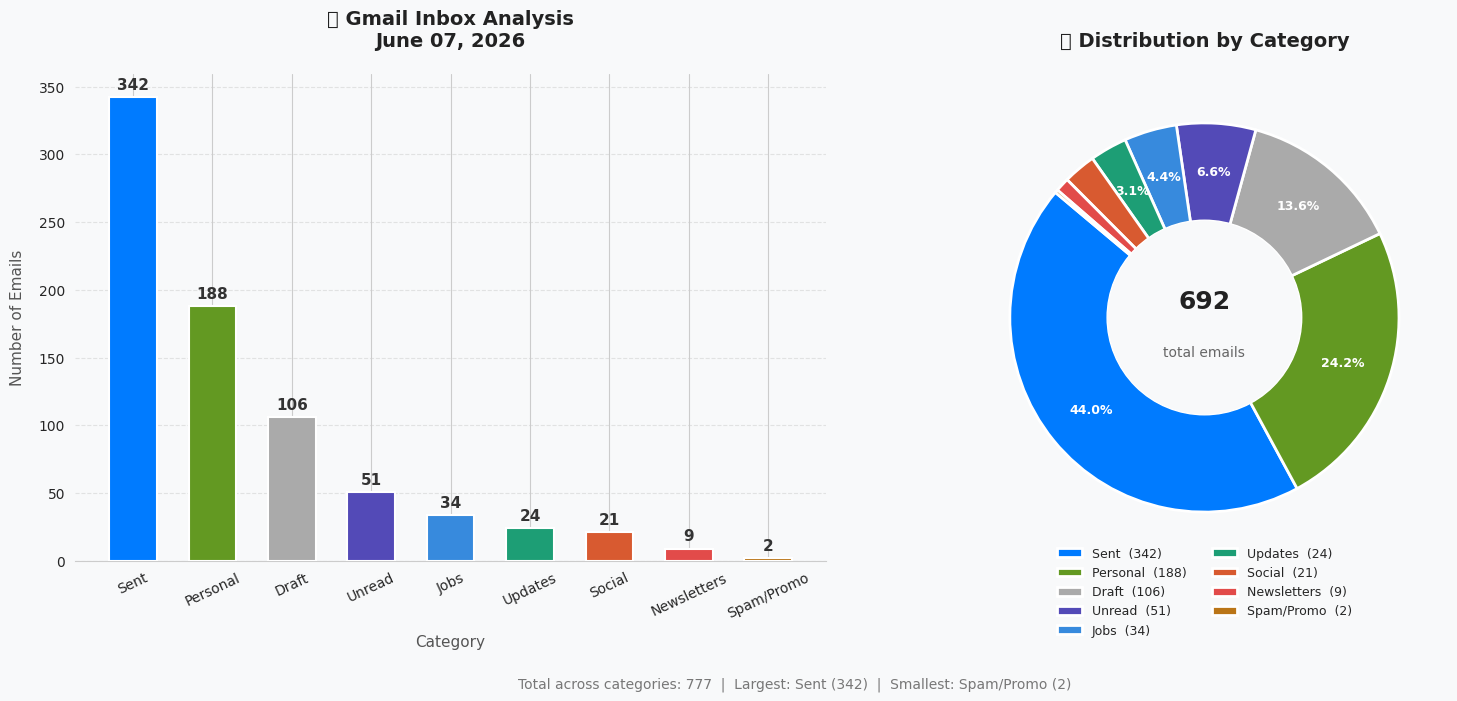


✅ Chart saved as gmail_analysis.png

📊 STATS SUMMARY
  Sent               342  (44.0%)
  Personal           188  (24.2%)
  Draft              106  (13.6%)
  Unread              51  (6.6%)
  Jobs                34  (4.4%)
  Updates             24  (3.1%)
  Social              21  (2.7%)
  Newsletters          9  (1.2%)
  Spam/Promo           2  (0.3%)
  ───────────────────────────────────
  TOTAL              777
  Inbox total        692


In [ ]:
#Get inbox total
profile     = service.users().getProfile(userId="me").execute()
inbox_total = profile.get("messagesTotal", 0)
print(f"\n  {'Inbox Total':<15} → {inbox_total:,}")

#  Fetch category counts (re-initialized)
CATEGORIES = {
    "Newsletters"  : "category:promotions unsubscribe",
    "Spam/Promo"   : "category:promotions -unsubscribe",
    "Jobs"         : "subject:job OR subject:career OR from:linkedin OR from:indeed OR from:glassdoor OR from:jobleads",
    "Personal"     : "category:personal",
    "Unread"       : "is:unread",
    "Social"       : "category:social",
    "Updates"      : "category:updates",
    "Draft"        : "in:draft",
    "Sent"         : "in:sent"
}

counts = {}
for label, query in CATEGORIES.items():
    msgs, page_token = [], None
    while True:
        result = service.users().messages().list(
            userId="me", q=query,
            pageToken=page_token, maxResults=500
        ).execute()
        msgs.extend(result.get("messages", []))
        page_token = result.get("nextPageToken")
        if not page_token:
            break
    counts[label] = len(msgs)
    print(f"  {label:<15} → {len(msgs):,}")
    time.sleep(0.3)

# ─── Prepare data
labels  = list(counts.keys())
values  = list(counts.values())
colors  = [
    "#E24B4A",   # Newsletters   — red
    "#BA7517",   # Spam/Promo    — orange
    "#378ADD",   # Jobs          — blue
    "#639922",   # Personal      — green
    "#534AB7",   # Unread        — purple
    "#D85A30",   # Social        — burnt orange
    "#1D9E75",   # Updates       — teal
    "#AAAAAA",   # Draft         — grey
    "#007bff",   # Sent          — darker blue
]

# ─── Sort descending ────────────────────────────────-
sorted_data   = sorted(zip(values, labels, colors), reverse=True)
values_sorted = [x[0] for x in sorted_data]
labels_sorted = [x[1] for x in sorted_data]
colors_sorted = [x[2] for x in sorted_data]

# ─── Build chart ──────────────────────────────────────
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor("#F8F9FA")

# ── Chart 1: Vertical bar chart ──────────────────────
ax1 = axes[0]
ax1.set_facecolor("#F8F9FA")

bars = ax1.bar(
    labels_sorted, values_sorted,
    color=colors_sorted,
    width=0.6,
    edgecolor="white",
    linewidth=1.5,
    zorder=3
)

# Add value labels on top of each bar
for bar, val in zip(bars, values_sorted):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(values_sorted) * 0.01,
        f"{val:,}",
        ha="center", va="bottom",
        fontsize=11, fontweight="bold",
        color="#333333"
    )

ax1.set_title(
    f"📧 Gmail Inbox Analysis\n{datetime.now().strftime('%B %d, %Y')}",
    fontsize=14, fontweight="bold", pad=20, color="#222222"
)
ax1.set_xlabel("Category", fontsize=11, labelpad=10, color="#555555")
ax1.set_ylabel("Number of Emails", fontsize=11, labelpad=10, color="#555555")
ax1.tick_params(axis="x", rotation=25, labelsize=10)
ax1.tick_params(axis="y", labelsize=10)
ax1.yaxis.grid(True, linestyle="--", alpha=0.5, zorder=0)
ax1.set_axisbelow(True)
ax1.spines[["top","right","left"]].set_visible(False)

# ── Chart 2: Horizontal donut / pie ──────────────────
ax2 = axes[1]
ax2.set_facecolor("#F8F9FA")

wedges, texts, autotexts = ax2.pie(
    values_sorted,
    labels=None,
    colors=colors_sorted,
    autopct=lambda p: f"{p:.1f}%" if p > 3 else "",
    startangle=140,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
    pctdistance=0.75,
)

for at in autotexts:
    at.set_fontsize(9)
    at.set_fontweight("bold")
    at.set_color("white")

# Draw inner circle for donut effect
centre_circle = plt.Circle((0, 0), 0.50, fc="#F8F9FA")
ax2.add_artist(centre_circle)

ax2.text(
    0, 0.08, f"{inbox_total:,}",
    ha="center", va="center",
    fontsize=18, fontweight="bold", color="#222222"
)
ax2.text(
    0, -0.18, "total emails",
    ha="center", va="center",
    fontsize=10, color="#666666"
)

ax2.legend(
    wedges, [f"{l}  ({v:,})" for l, v in zip(labels_sorted, values_sorted)],
    loc="lower center",
    bbox_to_anchor=(0.5, -0.18),
    ncol=2,
    fontsize=9,
    frameon=False
)

ax2.set_title(
    "📊 Distribution by Category",
    fontsize=14, fontweight="bold", pad=20, color="#222222"
)

# ── Stats summary below charts ───────────────────────
total_cats = sum(values_sorted)
fig.text(
    0.5, 0.01,
    f"Total across categories: {total_cats:,}  |  "
    f"Largest: {labels_sorted[0]} ({values_sorted[0]:,})  |  "
    f"Smallest: {labels_sorted[-1]} ({values_sorted[-1]:,})",
    ha="center", fontsize=10, color="#777777"
)

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig("gmail_analysis.png", dpi=150, bbox_inches="tight", facecolor="#F8F9FA")
plt.show()
print("\n✅ Chart saved as gmail_analysis.png")
print(f"\n📊 STATS SUMMARY")
print("=" * 40)
for l, v in zip(labels_sorted, values_sorted):
    pct = round(v / total_cats * 100, 1)
    print(f"  {l:<15} {v:>6,}  ({pct}%)")
print(f"  {'─'*35}")
print(f"  {'TOTAL':<15} {total_cats:>6,}")
print(f"  {'Inbox total':<15} {inbox_total:>6,}")